In [132]:
import cv2
from matplotlib import pyplot as plt

In [133]:
import numpy as np
from math import copysign

def rgb_to_lightness(color):
    color = color.tolist()
    r, g, b = color[0]/255, color[1]/255, color[2]/255


    l = 0.4122214708 * r + 0.5363325363 * g + 0.0514459929 * b
    m = 0.2119034982 * r + 0.6806995451 * g + 0.1073969566 * b
    s = 0.0883024619 * r + 0.2817188376 * g + 0.6299787005 * b

    l_ = pow(l, 1/3)
    m_ = pow(m, 1/3)
    s_ = pow(s, 1/3)

    return 0.2104542553*l_ + 0.7936177850*m_ - 0.0040720468*s_

def normalize_rgb(color):
    color = color.tolist()
    r, g, b = color[0]/255, color[1]/255, color[2]/255

    l = 0.4122214708 * r + 0.5363325363 * g + 0.0514459929 * b
    m = 0.2119034982 * r + 0.6806995451 * g + 0.1073969566 * b
    s = 0.0883024619 * r + 0.2817188376 * g + 0.6299787005 * b

    l_ = pow(l, 1/3)
    m_ = pow(m, 1/3)
    s_ = pow(s, 1/3)
    
    a = 1.9779984951*l_ - 2.4285922050*m_ + 0.4505937099*s_
    b = 0.0259040371*l_ + 0.7827717662*m_ - 0.8086757660*s_

    normalize_lightness = 0.55
    saturate_factor = 1.3
    a = copysign(pow(abs(a), 1/saturate_factor), a)
    b = copysign(pow(abs(b), 1/saturate_factor), b)

    _l = normalize_lightness + 0.3963377774 * a + 0.2158037573 * b
    _m = normalize_lightness - 0.1055613458 * a - 0.0638541728 * b
    _s = normalize_lightness - 0.0894841775 * a - 1.2914855480 * b

    l = pow(_l, 3) * 256
    m = pow(_m, 3) * 256
    s = pow(_s, 3) * 256

    r, g, b = +4.0767416621 * l - 3.3077115913 * m + 0.2309699292 * s, -1.2684380046 * l + 2.6097574011 * m - 0.3413193965 * s, -0.0041960863 * l - 0.7034186147 * m + 1.7076147010 * s
    return list((round(max(r, 0)), round(max(g, 0)), round(max(b, 0))))

In [134]:
img = cv2.imread(r'downscaled.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
lightness_map = [[]]

for i in range(img.shape[0]):
    lightness_map.append([])
    for j in range(img.shape[1]):
        lightness_map[i].append(rgb_to_lightness(img[i, j]))


In [135]:
normalized_color_map = []

for i in range(img.shape[0]):
    normalized_color_map.append([])
    for j in range(img.shape[1]):
        normalized_color_map[i].append(normalize_rgb(img[i,j]))

In [136]:
def load_characters_and_brightness(char_file, brightness_file):
  characters = []
  brightness_values = []
  with open(char_file, 'r', encoding='UTF-8') as f, open(brightness_file, 'r') as b:
    for char, brightness in zip(f, b):
      characters.append(char.strip())
      brightness_values.append(float(brightness.strip()))
  return characters, brightness_values

def brightness_to_char_index(brightness, brightness_values, min_brightness, max_brightness):
  normalized_brightness = (brightness - 0) / (1 - 0) * (max_brightness - min_brightness) + min_brightness
  closest_index = min(range(len(brightness_values)), key=lambda i: abs(brightness_values[i] - normalized_brightness))
  return closest_index

def image_to_char_art(image_data, characters, brightness_values, min_brightness, max_brightness):
  char_art = []
  for row in image_data:
    char_row = []
    for brightness in row:
      char_index = brightness_to_char_index(brightness, brightness_values, min_brightness, max_brightness)
      char_row.append(characters[char_index])
    char_art.append(char_row)
  return char_art

characters, brightness_values = load_characters_and_brightness("characters.txt", "character_density_16px.txt")

min_brightness = 180.828125
max_brightness = 243.10546875

result = image_to_char_art(lightness_map, characters, brightness_values, min_brightness, max_brightness)

196608


(array([2.0000e+00, 2.5200e+02, 2.9140e+03, 1.8922e+04, 4.2197e+04,
        3.6214e+04, 2.8329e+04, 2.8392e+04, 2.1454e+04, 1.7932e+04]),
 array([0.15769573, 0.24192616, 0.32615658, 0.41038701, 0.49461744,
        0.57884786, 0.66307829, 0.74730871, 0.83153914, 0.91576957,
        0.99999999]),
 <BarContainer object of 10 artists>)

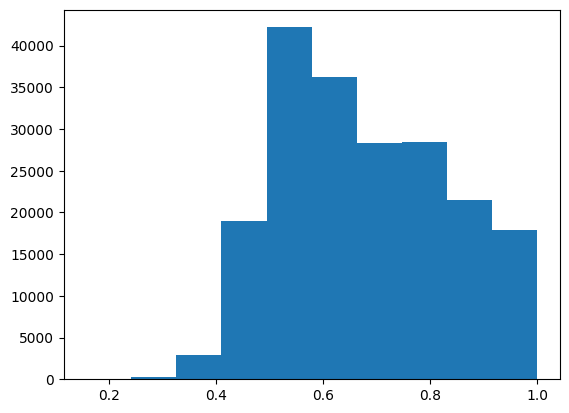

In [137]:
lightness_flat = []
for row in lightness_map:
    lightness_flat.extend(row)
print(len(lightness_flat))
plt.hist(lightness_flat)

In [138]:
def write_char_art_to_file(char_art, filename):
  """
  Writes the character art to a text file.

  Args:
      char_art: A 2D list containing the character art.
      filename: The name of the file to write the art to.
  """
  with open(filename, 'w', encoding='UTF-8') as f:
    for row in char_art:
      for char in row:
        f.write(char)
      f.write('\n')

write_char_art_to_file(result, "result.txt")


In [139]:
import json

with open("normalized_color_map.txt", 'w') as file:
  file.write(json.dumps(normalized_color_map))